# Análisis exploratorio complementario - Jeferson David Vargas Toca

Microproyecto DiabetesRisk

1. Calidad de datos (duplicados, valores inválidos).
2. Outliers en variables continuas.
3. Riesgo relativo por variable categórica.
4. Relación entre BMI, edad y diabetes.
5. Un **índice acumulado de factores de riesgo**, combinando las variables que se piensan usar en el formulario del tablero, para ver cómo escala la prevalencia de diabetes a medida que una persona acumula más factores.

## 0. Imports

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

TARGET = "Diabetes_binary"

## 1. Lectura de los datos

In [21]:
ruta_csv = "../data/diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(ruta_csv)
df.shape

(253680, 22)

## 2. Calidad de datos

Antes de mirar distribuciones, revisamos si hay problemas que puedan afectar el modelado: nulos, duplicados exactos y valores fisiológicamente imposibles.

In [22]:
print(df.isna().sum().sum(), "valores nulos")

duplicados = df.duplicated().sum()
print(duplicados, "filas duplicadas exactas "
      f"({duplicados / len(df):.1%} del total)")

bmi_invalido = (df["BMI"] <= 0).sum()
print(bmi_invalido, "registros con BMI <= 0 (posible dato inválido)")

0 valores nulos
24206 filas duplicadas exactas (9.5% del total)
0 registros con BMI <= 0 (posible dato inválido)


**Hallazgo:** el dataset no tiene nulos ni BMI inválido, pero sí un **9.5% de filas duplicadas exactas**. Esto no se menciona en el resto del análisis del equipo. No sabemos si son respuestas legítimamente repetidas en la encuesta BRFSS o artefactos de la construcción del dataset público; hay que decidir si se deduplican antes de entrenar el modelo, para no inflar artificialmente el tamaño de muestra.

## 3. Outliers en variables continuas

Usamos la regla del rango intercuartílico (IQR) sobre las tres variables continuas del dataset: `BMI`, `MentHlth` y `PhysHlth`.

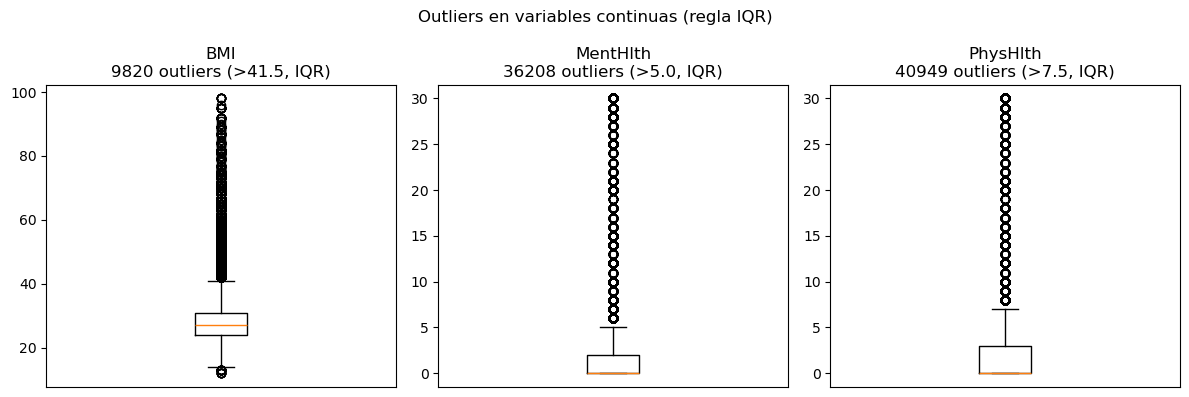

In [23]:
continuas = ["BMI", "MentHlth", "PhysHlth"]

fig, axes = plt.subplots(1, len(continuas), figsize=(4 * len(continuas), 4))
for ax, var in zip(axes, continuas):
    ax.boxplot(df[var], orientation="vertical")
    q1, q3 = df[var].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_sup = q3 + 1.5 * iqr
    n_outliers = (df[var] > limite_sup).sum()
    ax.set_title(f"{var}\n{n_outliers} outliers (>{limite_sup:.1f}, IQR)")
    ax.set_xticks([])
fig.suptitle("Outliers en variables continuas (regla IQR)")
fig.tight_layout()
plt.show()

**Hallazgo:** `MentHlth` y `PhysHlth` están fuertemente sesgadas hacia 0 (la mayoría reporta 0 días de mala salud en el último mes), por lo que casi cualquier valor alto se marca como "outlier" bajo IQR — son datos válidos, no errores. `BMI` sí tiene una cola larga hacia la derecha con valores muy altos que conviene revisar antes de escalar variables para el modelo.

## 4. Riesgo relativo por variable categórica

Medimos el **riesgo relativo**: la razón entre la tasa de diabetes del grupo de peor perfil y la del grupo de mejor perfil, para cada variable categórica/ordinal.

18 variables categoricas detectadas: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


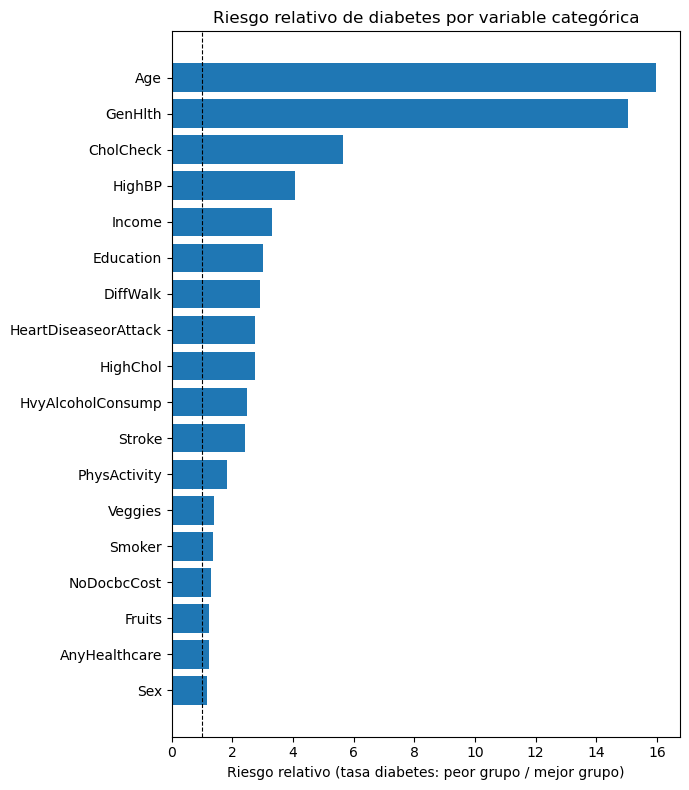

In [24]:
def columnas_categoricas(df, objetivo, umbral_valores_unicos=15):
    """Detecta columnas categoricas/ordinales: predictoras (todo menos el
    objetivo) con pocos valores unicos, para poder agruparlas y comparar
    tasas de diabetes entre grupos. BMI, MentHlth y PhysHlth quedan fuera
    porque tienen demasiados valores (84, 31 y 31) para que el agrupamiento
    sea interpretable."""
    predictoras = [c for c in df.columns if c != objetivo]
    return [c for c in predictoras if df[c].nunique() <= umbral_valores_unicos]


categoricas = columnas_categoricas(df, TARGET)
print(len(categoricas), "variables categoricas detectadas:", categoricas)

filas = []
for var in categoricas:
    tasas = df.groupby(var)[TARGET].mean()
    rr = tasas.max() / max(tasas.min(), 1e-9)
    filas.append((var, rr))

resumen = pd.DataFrame(filas, columns=["variable", "riesgo_relativo"]).sort_values("riesgo_relativo")

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(resumen["variable"], resumen["riesgo_relativo"])
ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Riesgo relativo (tasa diabetes: peor grupo / mejor grupo)")
ax.set_title("Riesgo relativo de diabetes por variable categórica")
fig.tight_layout()
plt.show()

**Hallazgo:** `Age` y `GenHlth` muestran la mayor separación entre grupos extremos (~15-16x), seguidas de `CholCheck` y `HighBP`. Es una lectura distinta y complementaria a la correlación de Pearson: aquí se ve el efecto en los extremos de cada variable, no solo la tendencia lineal promedio.

## 5. BMI, edad y diabetes (vista multivariada)

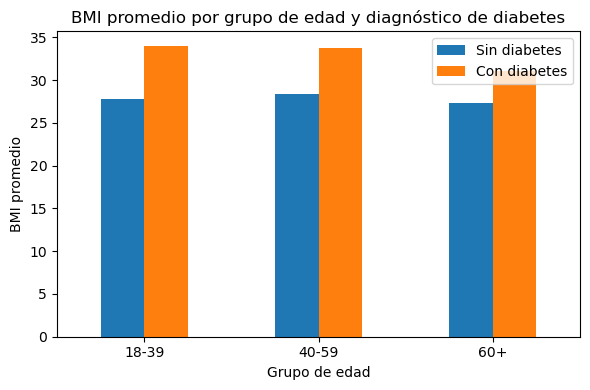

In [25]:
edad_bins = pd.cut(df["Age"], bins=[0, 4, 8, 13], labels=["18-39", "40-59", "60+"])
tabla = df.groupby([edad_bins, TARGET], observed=True)["BMI"].mean().unstack()

fig, ax = plt.subplots(figsize=(6, 4))
tabla.plot(kind="bar", ax=ax)
ax.set_ylabel("BMI promedio")
ax.set_xlabel("Grupo de edad")
ax.set_title("BMI promedio por grupo de edad y diagnóstico de diabetes")
ax.legend(["Sin diabetes", "Con diabetes"])
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

**Hallazgo:** en todos los grupos de edad, quienes tienen diabetes presentan un BMI promedio consistentemente más alto que quienes no la tienen, y la brecha se mantiene similar entre grupos de edad — el efecto del BMI no parece ser exclusivo de un rango etario particular.

## 6. Índice acumulado de factores de riesgo

Este es el análisis principal de este notebook. En vez de mirar cada variable por separado, construimos un puntaje sumando factores de riesgo presentes en cada persona y observamos cómo escala la prevalencia de diabetes a medida que se acumulan factores.

Los factores no se eligen a mano: se toman automáticamente las variables con mayor **riesgo relativo** (calculado en el punto 4) y, para cada una, una persona se marca como "en riesgo" si su valor cae en el subgrupo cuya tasa de diabetes supera el promedio poblacional — todo derivado de los datos, sin umbrales fijos inventados. `BMI`, al ser continua, se agrupa antes en cuartiles de la propia distribución.

In [26]:
def factores_de_alto_riesgo(df, objetivo, top_n=6):
    """Deriva automaticamente los factores de riesgo a partir del riesgo
    relativo (punto 4): toma las top_n variables con mayor riesgo relativo
    y marca a cada persona segun si su valor cae en el subgrupo cuya tasa
    de diabetes supera el promedio poblacional. BMI se incluye binandola
    en cuartiles de su propia distribucion (sin umbral fijo)."""
    df_bin = df.copy()
    df_bin["BMI (por cuartil)"] = pd.qcut(df["BMI"], 4, labels=False, duplicates="drop")

    candidatas = columnas_categoricas(df, objetivo) + ["BMI (por cuartil)"]
    tasa_global = df[objetivo].mean()

    riesgos = []
    for var in candidatas:
        tasas = df_bin.groupby(var)[objetivo].mean()
        rr = tasas.max() / max(tasas.min(), 1e-9)
        riesgos.append((var, rr, tasas))

    top = sorted(riesgos, key=lambda x: x[1], reverse=True)[:top_n]
    print("Variables seleccionadas (mayor riesgo relativo):",
          [(var, round(rr, 2)) for var, rr, _ in top])

    factores = pd.DataFrame({
        var: df_bin[var].map(tasas) > tasa_global
        for var, rr, tasas in top
    })
    return factores


factores = factores_de_alto_riesgo(df, TARGET)
puntaje = factores.sum(axis=1)

resumen_riesgo = pd.DataFrame({
    "n_personas": puntaje.value_counts().sort_index(),
    "prevalencia_diabetes": df.groupby(puntaje)[TARGET].mean(),
})
resumen_riesgo["pct_poblacion"] = resumen_riesgo["n_personas"] / len(df) * 100
resumen_riesgo

Variables seleccionadas (mayor riesgo relativo): [('Age', 15.96), ('GenHlth', 15.06), ('CholCheck', 5.65), ('BMI (por cuartil)', 4.65), ('HighBP', 4.05), ('Income', 3.29)]


,n_personas,prevalencia_diabetes,pct_poblacion
0,1808,0.001106,0.712709
1,31610,0.008067,12.460580
2,49451,0.028432,19.493456
3,56869,0.076316,22.417613
4,54571,0.166151,21.511747
5,41617,0.300550,16.405314
6,17754,0.437535,6.998581


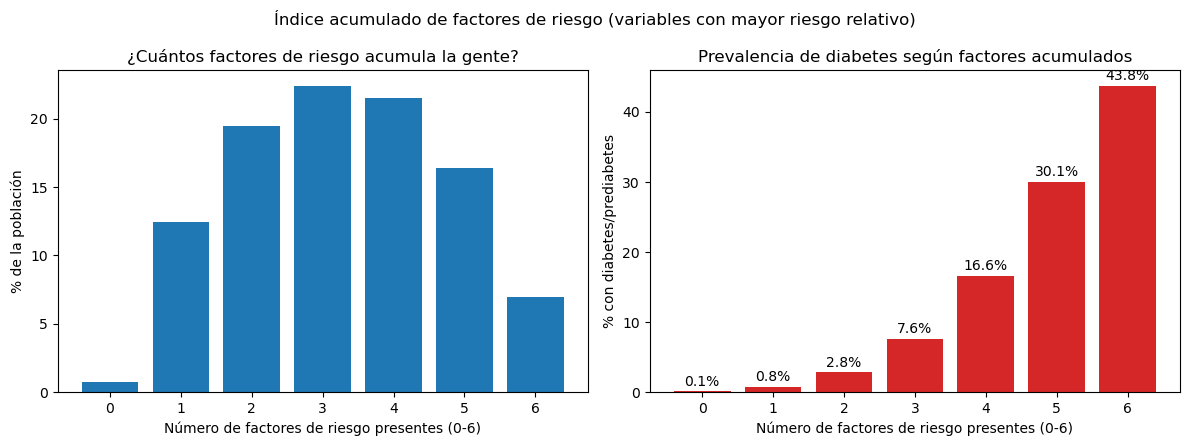

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.bar(resumen_riesgo.index.astype(str), resumen_riesgo["pct_poblacion"])
ax1.set_xlabel("Número de factores de riesgo presentes (0-6)")
ax1.set_ylabel("% de la población")
ax1.set_title("¿Cuántos factores de riesgo acumula la gente?")

bars = ax2.bar(resumen_riesgo.index.astype(str), resumen_riesgo["prevalencia_diabetes"] * 100, color="tab:red")
ax2.bar_label(bars, fmt="%.1f%%", padding=2)
ax2.set_xlabel("Número de factores de riesgo presentes (0-6)")
ax2.set_ylabel("% con diabetes/prediabetes")
ax2.set_title("Prevalencia de diabetes según factores acumulados")

fig.suptitle("Índice acumulado de factores de riesgo (variables con mayor riesgo relativo)")
fig.tight_layout()
plt.show()

**Conclusión:** la prevalencia de diabetes escala de forma casi monótona con el número de factores de riesgo presentes (de las 6 variables con mayor riesgo relativo: `Age`, `GenHlth`, `CholCheck`, `BMI` por cuartil, `HighBP`, `Income`): de **0.1%** con 0 factores a **43.8%** con los 6 presentes a la vez. Aunque cada variable por separado ya mostraba asociación con diabetes, verlas combinadas evidencia un efecto acumulativo mucho más fuerte que cualquier variable individual. Nótese que, al ser un ranking automático por riesgo relativo, entraron variables como `CholCheck` e `Income` que no son factores de riesgo clínicos en sí mismos (posible sesgo: quien se hace chequeos de colesterol probablemente ya tiene sospecha de problemas de salud; el ingreso es un determinante social, no biológico) — para usar esto en el tablero conviene filtrar antes a variables clínicamente accionables.